In [ ]:
import pandas as pd
import numpy as np

from datasets import load_dataset

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = load_dataset("SetFit/bbc-news")

df

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 1225
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 1000
    })
})

In [4]:
df["train"][0]

{'text': 'wales want rugby league training wales could follow england s lead by training with a rugby league club.  england have already had a three-day session with leeds rhinos  and wales are thought to be interested in a similar clinic with rivals st helens. saints coach ian millward has given his approval  but if it does happen it is unlikely to be this season. saints have a week s training in portugal next week  while wales will play england in the opening six nations match on 5 february.  we have had an approach from wales   confirmed a saints spokesman.  it s in the very early stages but it is something we are giving serious consideration to.  st helens  who are proud of their welsh connections  are obvious partners for the welsh rugby union  despite a spat in 2001 over the collapse of kieron cunningham s proposed £500 000 move to union side swansea. a similar cross-code deal that took iestyn harris from leeds to cardiff in 2001 did go through  before the talented stand-off retu

In [5]:
train_df = pd.DataFrame(df["train"])
test_df = pd.DataFrame(df["test"])

train_df.head()

,text,label,label_text
0,wales want rugby league training wales could f...,2,sport
1,china aviation seeks rescue deal scandal-hit j...,1,business
2,rock band u2 break ticket record u2 have smash...,3,entertainment
3,markets signal brazilian recovery the brazilia...,1,business
4,tough rules for ringtone sellers firms that fl...,0,tech


In [6]:
print(train_df.shape)
print(train_df.columns)

train_df["label_text"].value_counts()

(1225, 3)
Index(['text', 'label', 'label_text'], dtype='object')


label_text
business         286
sport            275
politics         242
tech             212
entertainment    210
Name: count, dtype: int64

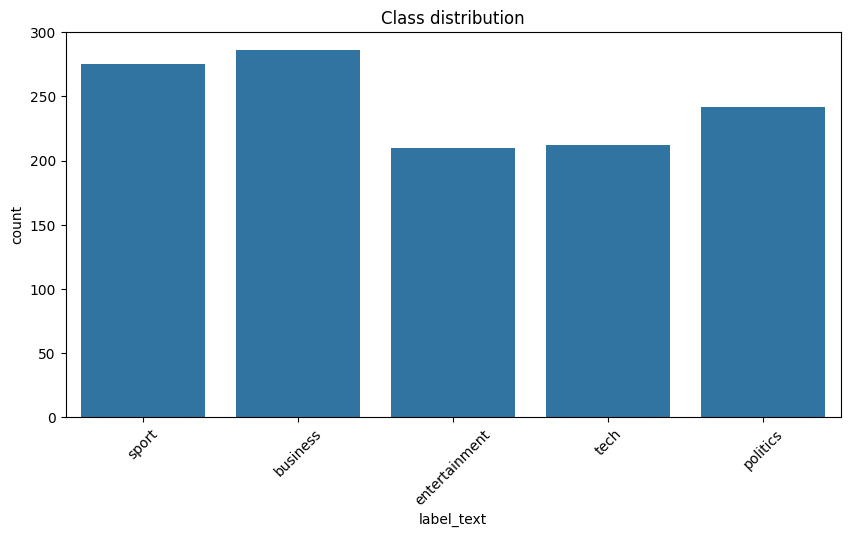

In [7]:
plt.figure(figsize=(10,5))
sns.countplot(data=train_df, x="label_text")
plt.xticks(rotation=45)
plt.title("Class distribution")
plt.show()

In [ ]:
!python -m spacy download en_core_web_sm

In [8]:
import spacy
import re
import string

nlp = spacy.load("en_core_web_sm")

stopwords = nlp.Defaults.stop_words

In [9]:
def clean_text(text):
    # lowercase
    text = text.lower()
    
    # remove punctuation + digits
    text = re.sub(r"[^a-z\s]", " ", text)
    
    # spaCy processing
    doc = nlp(text)
    
    tokens = []
    for token in doc:
        if token.text in stopwords:
            continue
        if token.is_space:
            continue
        lemma = token.lemma_
        if len(lemma) > 2:
            tokens.append(lemma)
    
    return " ".join(tokens)

In [10]:
sample = train_df["text"].iloc[0]

print("RAW:\n", sample[:500])
print("\nCLEAN:\n", clean_text(sample)[:500])

RAW:
 wales want rugby league training wales could follow england s lead by training with a rugby league club.  england have already had a three-day session with leeds rhinos  and wales are thought to be interested in a similar clinic with rivals st helens. saints coach ian millward has given his approval  but if it does happen it is unlikely to be this season. saints have a week s training in portugal next week  while wales will play england in the opening six nations match on 5 february.  we have ha

CLEAN:
 wale want rugby league training wale follow england lead training rugby league club england day session leed rhino wale think interested similar clinic rival helen saint coach ian millward give approval happen unlikely season saint week training portugal week wale play england opening nation match february approach wale confirm saint spokesman early stage give consideration helen proud welsh connection obvious partner welsh rugby union despite spat collapse kieron cunningham prop

In [11]:
train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [13]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

In [14]:
X_train = tfidf.fit_transform(train_df["clean_text"])
X_test = tfidf.transform(test_df["clean_text"])

y_train = train_df["label"]
y_test = test_df["label"]

In [15]:
print(X_train.shape)
print(X_test.shape)

(1225, 5000)
(1000, 5000)


Baseline Model 1 — Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

In [17]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
y_pred_lr = log_reg.predict(X_test)

In [19]:
from sklearn.metrics import classification_report, accuracy_score

In [20]:
print("LOGISTIC REGRESSION RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.966
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       189
           1       0.95      0.94      0.95       224
           2       0.99      1.00      0.99       236
           3       0.99      0.96      0.98       176
           4       0.94      0.98      0.96       175

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



Baseline Model 2 — SVM

In [21]:
from sklearn.svm import LinearSVC

In [22]:
svm = LinearSVC()
svm.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [23]:
y_pred_svm = svm.predict(X_test)

In [24]:
print("SVM RESULTS")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM RESULTS
Accuracy: 0.969
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       189
           1       0.96      0.95      0.95       224
           2       0.99      0.99      0.99       236
           3       1.00      0.95      0.98       176
           4       0.93      0.98      0.96       175

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



Confusion Matrix

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

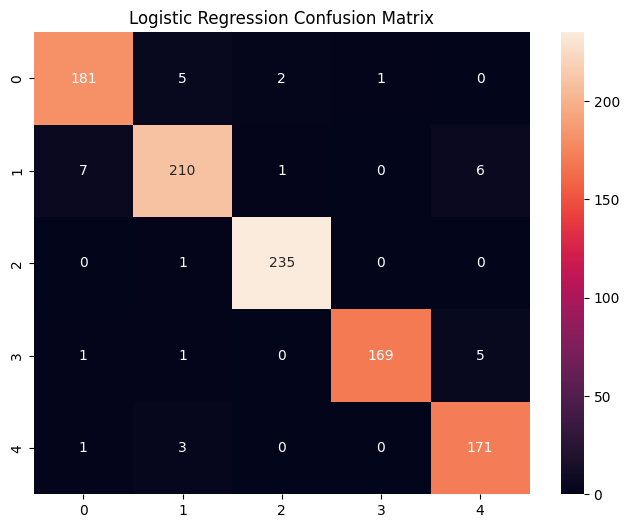

In [26]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Feature importance

In [28]:
feature_names = tfidf.get_feature_names_out()

In [29]:
import numpy as np

def show_top_words(model, class_index, n=10):
    coef = model.coef_[class_index]
    top_idx = np.argsort(coef)[-n:]
    return [feature_names[i] for i in top_idx]

In [30]:
for i in range(len(log_reg.classes_)):
    print(f"Class {log_reg.classes_[i]}:", show_top_words(log_reg, i))

Class 0: ['site', 'digital', 'people', 'phone', 'mobile', 'software', 'game', 'computer', 'technology', 'user']
Class 1: ['price', 'airline', 'economic', 'share', 'growth', 'economy', 'bank', 'market', 'firm', 'company']
Class 2: ['team', 'club', 'coach', 'rugby', 'injury', 'play', 'match', 'cup', 'player', 'win']
Class 3: ['actor', 'song', 'chart', 'music', 'album', 'singer', 'award', 'band', 'star', 'film']
Class 4: ['secretary', 'say', 'government', 'lord', 'tory', 'blair', 'minister', 'election', 'labour', 'party']


BERTopic (Modern Topic Modeling Pipeline)

In [ ]:
!pip install bertopic sentence-transformers umap-learn hdbscan

In [31]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

In [32]:
docs = train_df["clean_text"].tolist()

In [33]:
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5
)

In [ ]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

In [35]:
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    min_topic_size=20,
    calculate_probabilities=True,
    verbose=True
)

In [ ]:
topics, probs = topic_model.fit_transform(docs)

In [37]:
topic_model.get_topic_info().head(10)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,49,-1_file_music_dvd_say,"[file, music, dvd, say, peer, network, softwar...",[court mull file share future judge supreme co...
1,0,296,0_say_year_company_market,"[say, year, company, market, firm, rise, growt...",[ore cost hit global steel firm share steel fi...
2,1,239,1_say_party_labour_election,"[say, party, labour, election, government, min...",[terror power expose tyranny lord chancellor d...
3,2,177,2_game_england_play_player,"[game, england, play, player, win, club, team,...",[giggs hand wale lead role ryan giggs captain ...
4,3,133,3_mobile_phone_people_say,"[mobile, phone, people, say, technology, servi...",[look music drive mobile mobile phone enjoy bo...
5,4,113,4_film_award_good_star,"[film, award, good, star, actor, win, director...",[critic laud comedy sideways road trip comedy ...
6,5,76,5_music_song_band_good,"[music, song, band, good, artist, year, award,...",[grammys honour soul star charle memory soul l...
7,6,57,6_olympic_win_race_world,"[olympic, win, race, world, year, gold, europe...",[gardener win double glasgow britain jason gar...
8,7,47,7_match_open_win_play,"[match, open, win, play, australian, final, te...",[moya clinch cup spain spain win davis cup sec...
9,8,38,8_security_attack_mail_site,"[security, attack, mail, site, user, program, ...",[get official virus alert site rapid alert ser...


In [38]:
topic_model.get_topic(0)

[('say', np.float64(0.046271020284496804)),
 ('year', np.float64(0.035326697763242175)),
 ('company', np.float64(0.031475869900925324)),
 ('market', np.float64(0.030031996404183123)),
 ('firm', np.float64(0.028255233283646777)),
 ('rise', np.float64(0.027103833250640738)),
 ('growth', np.float64(0.026051559781009617)),
 ('bank', np.float64(0.025291722620730168)),
 ('price', np.float64(0.02410192299143715)),
 ('rate', np.float64(0.023035466221904534))]

In [39]:
train_df["topic"] = topics

In [40]:
print("Outliers (-1 topic):", sum(train_df["topic"] == -1))

Outliers (-1 topic): 49


In [41]:
topic_model.visualize_topics()

In [42]:
topic_model.visualize_barchart(top_n_topics=10)

In [43]:
import pandas as pd

pd.crosstab(train_df["label_text"], train_df["topic"])

topic,-1,0,1,2,3,4,5,6,7,8
label_text,,,,,,,,,,
business,4,267,8,3,4,0,0,0,0,0
entertainment,17,3,3,0,1,112,73,1,0,0
politics,0,16,224,2,0,0,0,0,0,0
sport,0,1,0,171,0,0,0,56,47,0
tech,28,9,4,1,128,1,3,0,0,38


VISUALIZATION

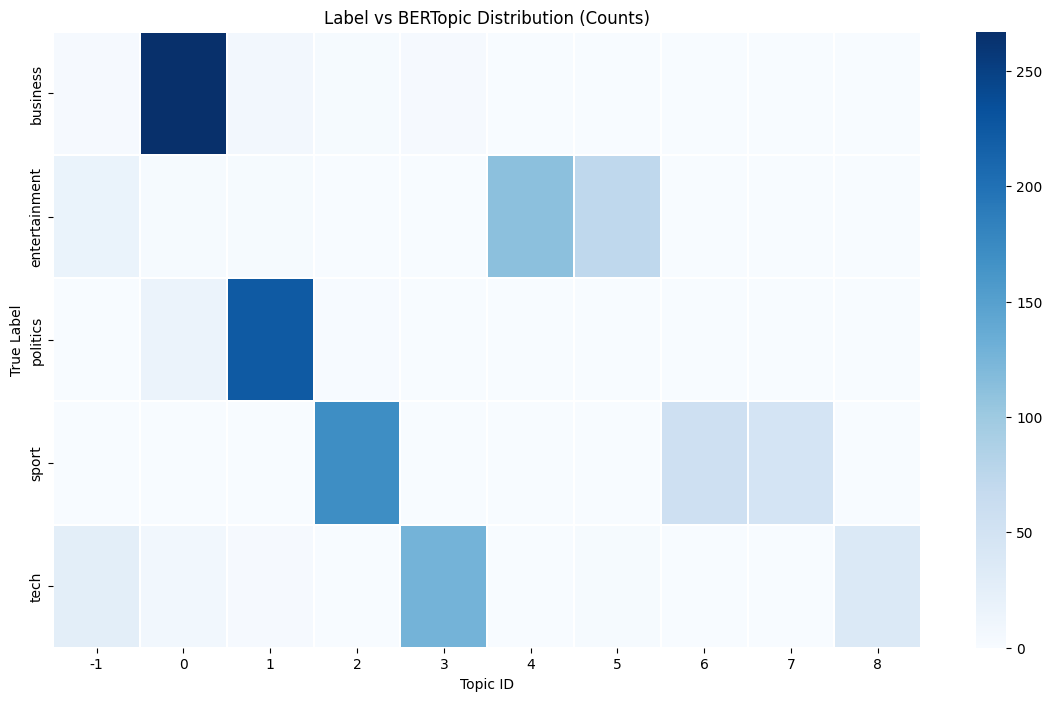

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# cross-tab: raw counts
ct = pd.crosstab(train_df["label_text"], train_df["topic"])

plt.figure(figsize=(14,8))
sns.heatmap(ct, cmap="Blues", linewidths=0.3)

plt.title("Label vs BERTopic Distribution (Counts)")
plt.xlabel("Topic ID")
plt.ylabel("True Label")
plt.show()

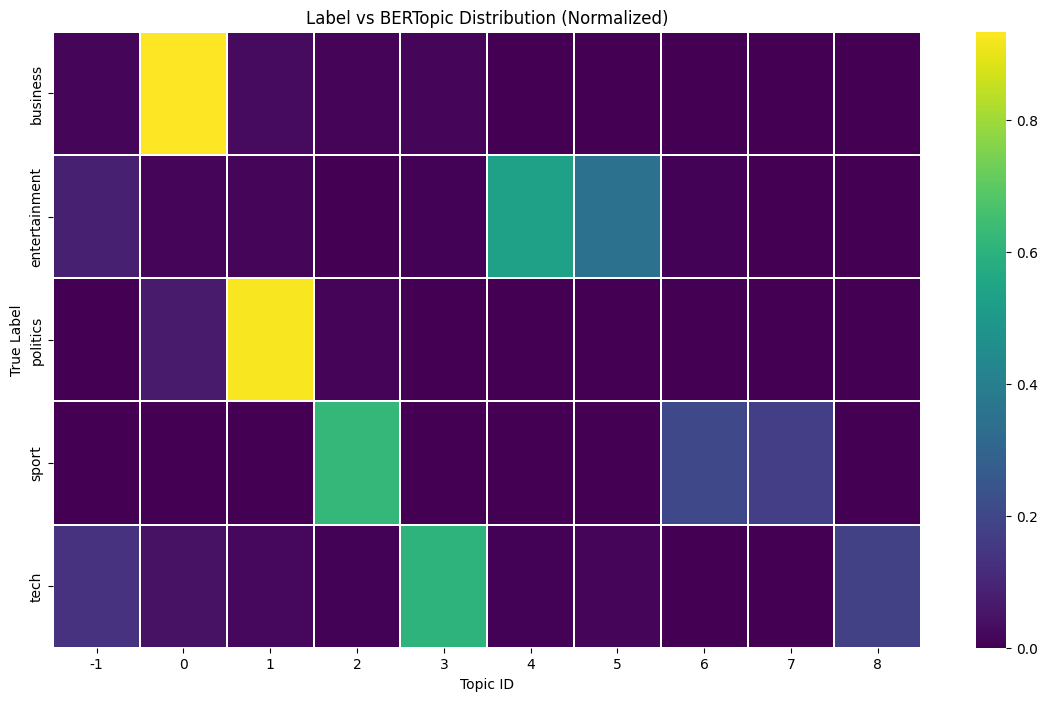

In [45]:
ct_norm = pd.crosstab(
    train_df["label_text"],
    train_df["topic"],
    normalize="index"
)

plt.figure(figsize=(14,8))
sns.heatmap(ct_norm, cmap="viridis", linewidths=0.3)

plt.title("Label vs BERTopic Distribution (Normalized)")
plt.xlabel("Topic ID")
plt.ylabel("True Label")
plt.show()

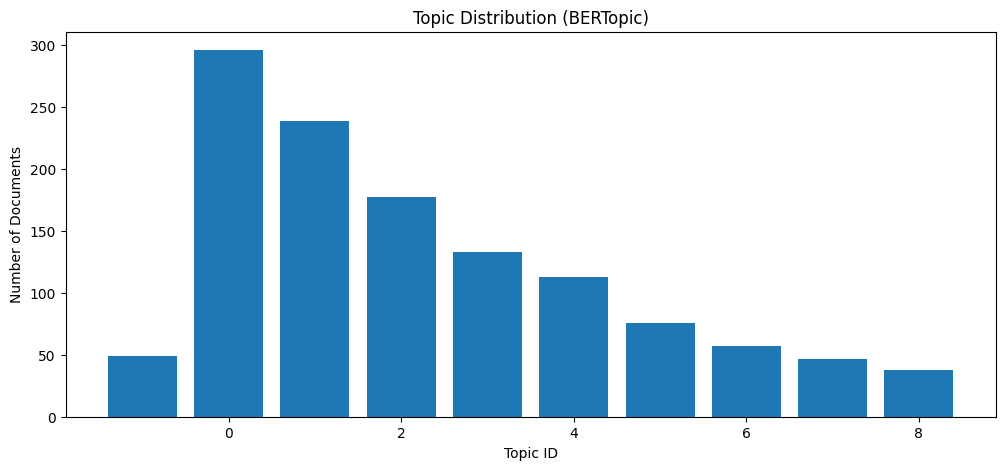

In [46]:
topic_counts = train_df["topic"].value_counts().sort_index()

plt.figure(figsize=(12,5))
plt.bar(topic_counts.index, topic_counts.values)

plt.title("Topic Distribution (BERTopic)")
plt.xlabel("Topic ID")
plt.ylabel("Number of Documents")
plt.show()

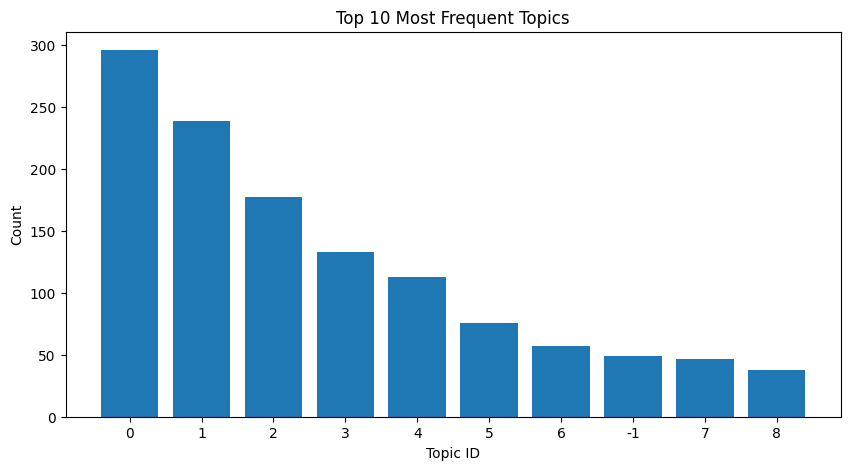

In [47]:
top_topics = topic_counts.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_topics.index.astype(str), top_topics.values)

plt.title("Top 10 Most Frequent Topics")
plt.xlabel("Topic ID")
plt.ylabel("Count")
plt.show()

In [48]:
topic_model.visualize_documents(docs)

Batches: 100%|██████████| 39/39 [00:34<00:00,  1.14it/s]


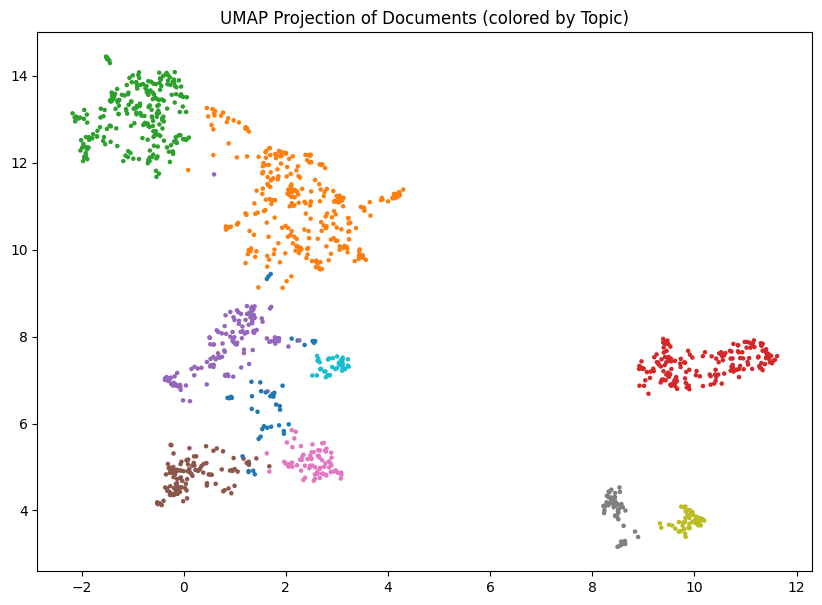

In [49]:
from umap import UMAP
import matplotlib.pyplot as plt

# embeddings (FIX)
embedding = embedding_model.encode(docs, show_progress_bar=True)

umap_model = UMAP(
    n_neighbors=15,
    n_components=2,
    metric="cosine",
    random_state=42
)

embedding_2d = umap_model.fit_transform(embedding)

plt.figure(figsize=(10,7))

plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    c=train_df["topic"],
    cmap="tab10",
    s=5
)

plt.title("UMAP Projection of Documents (colored by Topic)")
plt.show()